Some imports:

In [ ]:
using CairoMakie
using Distributions
using Enzyme
using LaTeXStrings
using PairPlots
using StatsFuns
using TruncatedPopulations
using Turing

Set up the true population parameters:

In [2]:
mu_true = 1.0
sigma_true = 0.15

0.15

Draw some samples from the population:

In [56]:
N = 100

qs_true = rand(truncated(Normal(mu_true, sigma_true), 0.0, 1.0), N)

100-element Vector{Float64}:
 0.7179546084521837
 0.9283845725376263
 0.8546137355582463
 0.9411778140810584
 0.8365852607047184
 0.811418848491257
 0.9156559816324596
 0.8349792186846459
 0.9840560028625864
 0.7859234385798688
 ⋮
 0.8691685387336539
 0.9607282178645156
 0.8681733682521799
 0.99945366248434
 0.557300105472464
 0.7230394703998915
 0.7865181733067992
 0.8158280917368
 0.9104619905556305

This is what they look like:

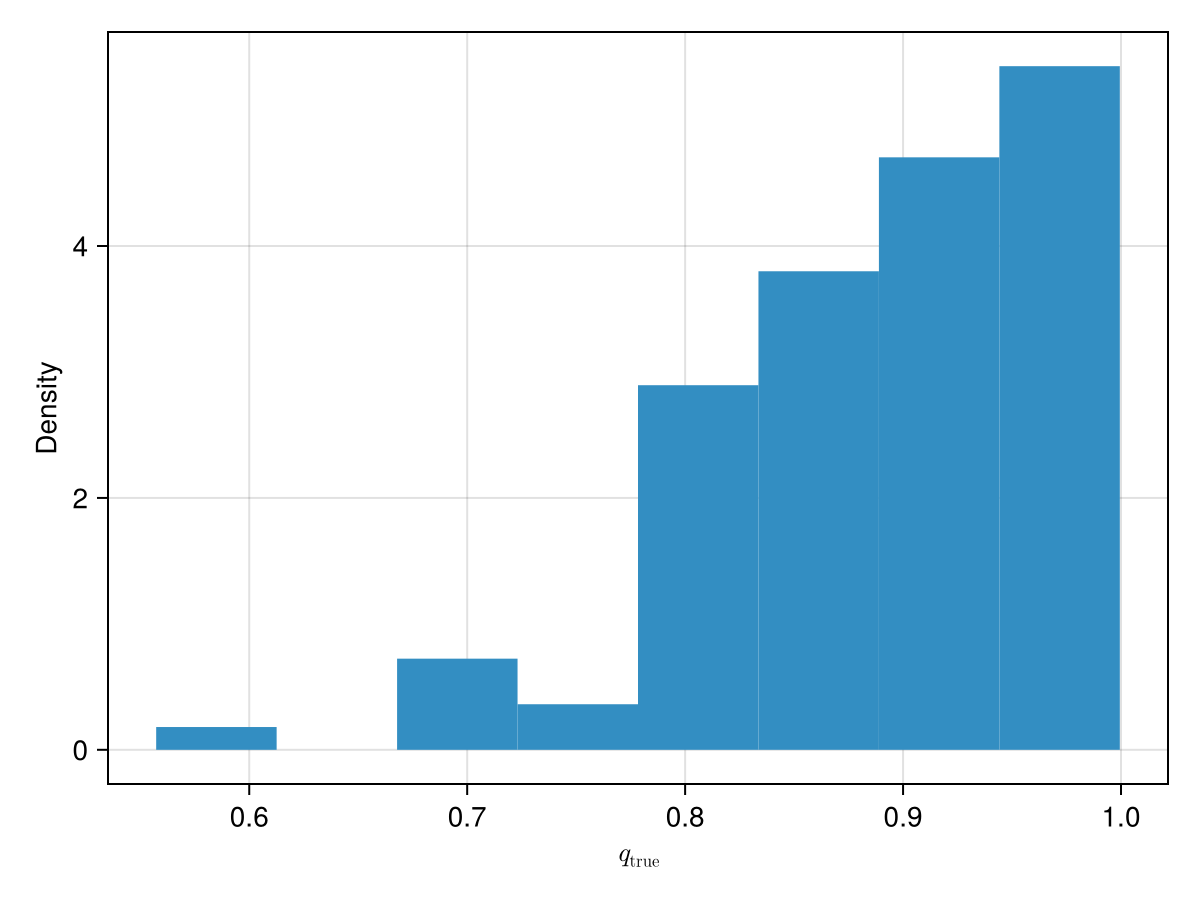

In [57]:
f = Figure()
a = Axis(f[1,1], xlabel=L"q_\mathrm{true}", ylabel="Density")
hist!(a, qs_true, normalization=:pdf, bins=scotts_rule_bins(qs_true))
f

Generate mock observations of these samples (observational noise is additive Gaussian, with a width a bit more than the population width):

In [58]:
sigma_obs = 0.25

qs_obs = [rand(Normal(q, sigma_obs)) for q in qs_true]

100-element Vector{Float64}:
 0.8075150617592195
 1.1253346448481847
 0.7793267190653494
 1.3389893601877936
 1.301225988758882
 0.706795365513184
 0.7422694720342706
 1.0298499209377359
 0.6596340982789675
 0.3948959436664346
 ⋮
 0.6925586293779651
 1.1113577018812855
 1.0351906763048477
 1.1809611745609598
 0.7200418549925343
 0.41267807489930686
 1.5087805189385883
 0.9609875718930382
 0.5444583521169903

Here are the observed $q$:

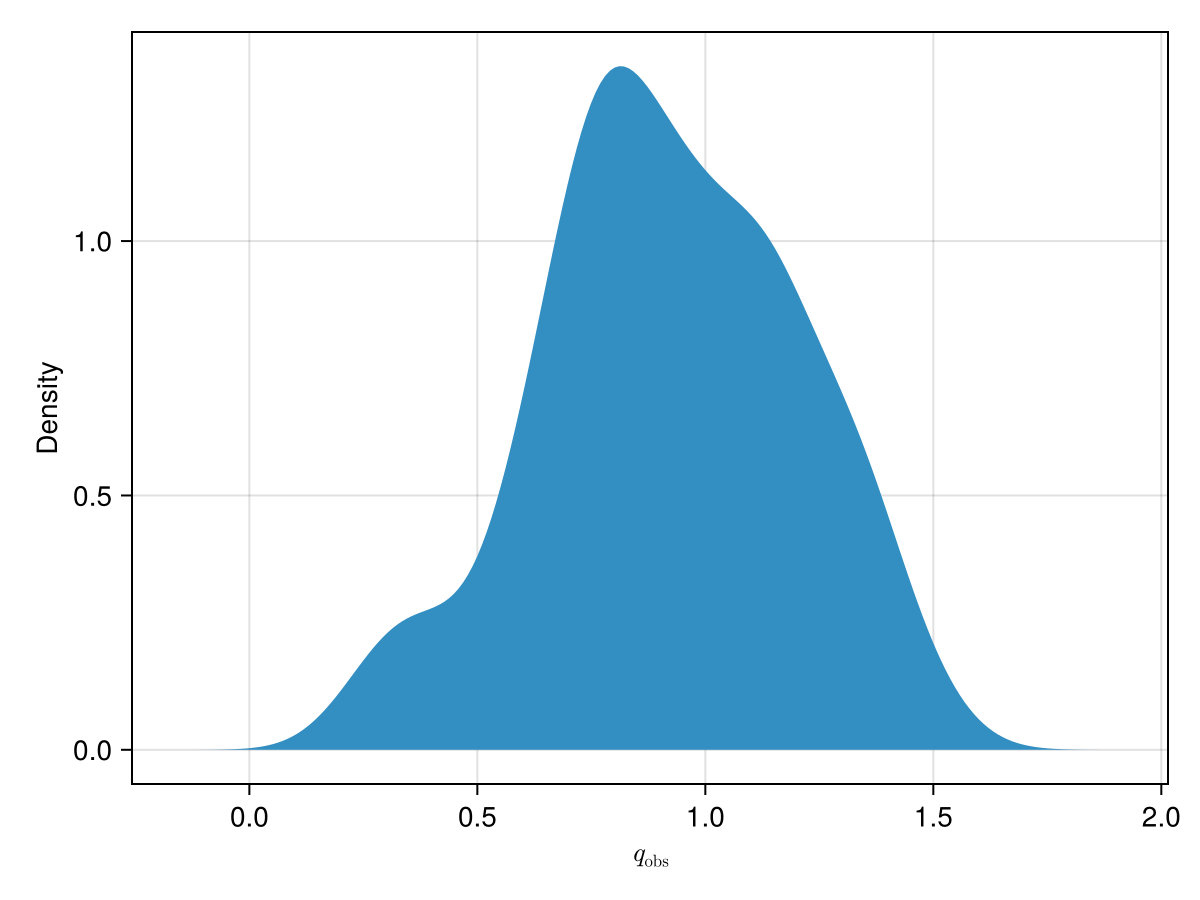

In [59]:
f = Figure()
a = Axis(f[1,1], xlabel=L"q_\mathrm{obs}", ylabel="Density")
density!(a, qs_obs)
f

This is an "exact" model, that samples over $\mu$, $\sigma$, and all the true $qs$; I used the non-centered parameterization (giving each sampled $q_\mathrm{raw}$ component a $N(0,1) \, T\left[ -\mu/\sigma, \left( 1 - \mu\right)/\sigma\right]$ distribution, and then deriving $q = \mu + \sigma * q_\mathrm{raw}$) for better sampling, though the sampling still sort of sucks....

In [60]:
@model function exact_likelihood_model(qs_obs, sigma_obs)
    mu ~ Normal(0.0, 1.0)
    sigma ~ truncated(Normal(0.0, 1.0), 0.0, Inf)

    qs_raw = Vector{Float64}(undef, length(qs_obs))
    for i in eachindex(qs_raw)
        qs_raw[i] ~ truncated(Normal(0, 1), -mu / sigma, (1 - mu) / sigma)
    end
    qs := mu .+ sigma .* qs_raw

    for i in eachindex(qs_obs)
        qs_obs[i] ~ Normal(qs[i], sigma_obs)
    end
end

exact_likelihood_model (generic function with 2 methods)

In [61]:
exact_trace = sample(exact_likelihood_model(qs_obs, sigma_obs), NUTS(1000, 0.8; adtype=AutoEnzyme(mode=Enzyme.set_runtime_activity(Enzyme.Reverse))), 1000)

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.2
└ @ Turing.Inference /Users/wfarr/.julia/packages/Turing/H4T0b/src/mcmc/hmc.jl:226
Sampling   0%|▎                                         |  ETA: 0:04:08
Sampling   1%|▍                                         |  ETA: 0:02:11
Sampling   2%|▋                                         |  ETA: 0:01:33
Sampling   2%|▉                                         |  ETA: 0:01:18
Sampling   2%|█                                         |  ETA: 0:01:05
Sampling   3%|█▎                                        |  ETA: 0:00:56
Sampling   4%|█▌                                        |  ETA: 0:00:51
Sampling   4%|█▋                                        |  ETA: 0:00:48
Sampling   4%|█▉                                        |  ETA: 0:00:44
Sampling   5%|██▏                                       |  ETA: 0:00:40
Sampling   6%|██▎                                       |  ETA: 0:00:37
Sampling   6%

Chains MCMC chain (1000×216×1 Array{Float64, 3}):

Iterations        = 1001:1:2000
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 7.53 seconds
Compute duration  = 7.53 seconds
parameters        = mu, sigma, qs_raw[1], qs_raw[2], qs_raw[3], qs_raw[4], qs_raw[5], qs_raw[6], qs_raw[7], qs_raw[8], qs_raw[9], qs_raw[10], qs_raw[11], qs_raw[12], qs_raw[13], qs_raw[14], qs_raw[15], qs_raw[16], qs_raw[17], qs_raw[18], qs_raw[19], qs_raw[20], qs_raw[21], qs_raw[22], qs_raw[23], qs_raw[24], qs_raw[25], qs_raw[26], qs_raw[27], qs_raw[28], qs_raw[29], qs_raw[30], qs_raw[31], qs_raw[32], qs_raw[33], qs_raw[34], qs_raw[35], qs_raw[36], qs_raw[37], qs_raw[38], qs_raw[39], qs_raw[40], qs_raw[41], qs_raw[42], qs_raw[43], qs_raw[44], qs_raw[45], qs_raw[46], qs_raw[47], qs_raw[48], qs_raw[49], qs_raw[50], qs_raw[51], qs_raw[52], qs_raw[53], qs_raw[54], qs_raw[55], qs_raw[56], qs_raw[57], qs_raw[58], qs_raw[59], qs_raw[60], qs_raw[61], qs_raw[62], qs_raw[63], qs_raw[64], qs_raw[65], qs

The sampling is sorta shit, but not so terrible that it's not worth looking at the result:

In [62]:
describe(exact_trace)

Chains MCMC chain (1000×216×1 Array{Float64, 3}):

Iterations        = 1001:1:2000
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 7.53 seconds
Compute duration  = 7.53 seconds
parameters        = mu, sigma, qs_raw[1], qs_raw[2], qs_raw[3], qs_raw[4], qs_raw[5], qs_raw[6], qs_raw[7], qs_raw[8], qs_raw[9], qs_raw[10], qs_raw[11], qs_raw[12], qs_raw[13], qs_raw[14], qs_raw[15], qs_raw[16], qs_raw[17], qs_raw[18], qs_raw[19], qs_raw[20], qs_raw[21], qs_raw[22], qs_raw[23], qs_raw[24], qs_raw[25], qs_raw[26], qs_raw[27], qs_raw[28], qs_raw[29], qs_raw[30], qs_raw[31], qs_raw[32], qs_raw[33], qs_raw[34], qs_raw[35], qs_raw[36], qs_raw[37], qs_raw[38], qs_raw[39], qs_raw[40], qs_raw[41], qs_raw[42], qs_raw[43], qs_raw[44], qs_raw[45], qs_raw[46], qs_raw[47], qs_raw[48], qs_raw[49], qs_raw[50], qs_raw[51], qs_raw[52], qs_raw[53], qs_raw[54], qs_raw[55], qs_raw[56], qs_raw[57], qs_raw[58], qs_raw[59], qs_raw[60], qs_raw[61], qs_raw[62], qs_raw[63], qs_raw[64], qs_raw[65], qs

We get a reasonable (or at least *consistent*) estimate of the population parameters:

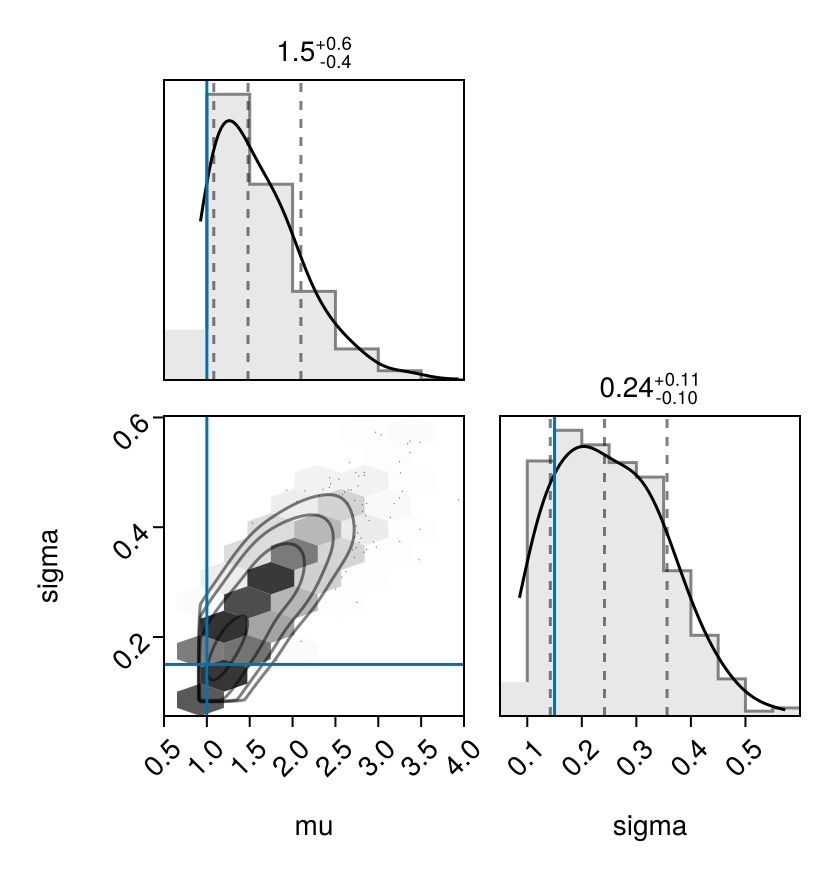

In [63]:
pairplot(exact_trace[[:mu, :sigma]], PairPlots.Truth((; mu = mu_true, sigma = sigma_true)))

Just to check, here are some random components of $q$ that are measured by the model as well:

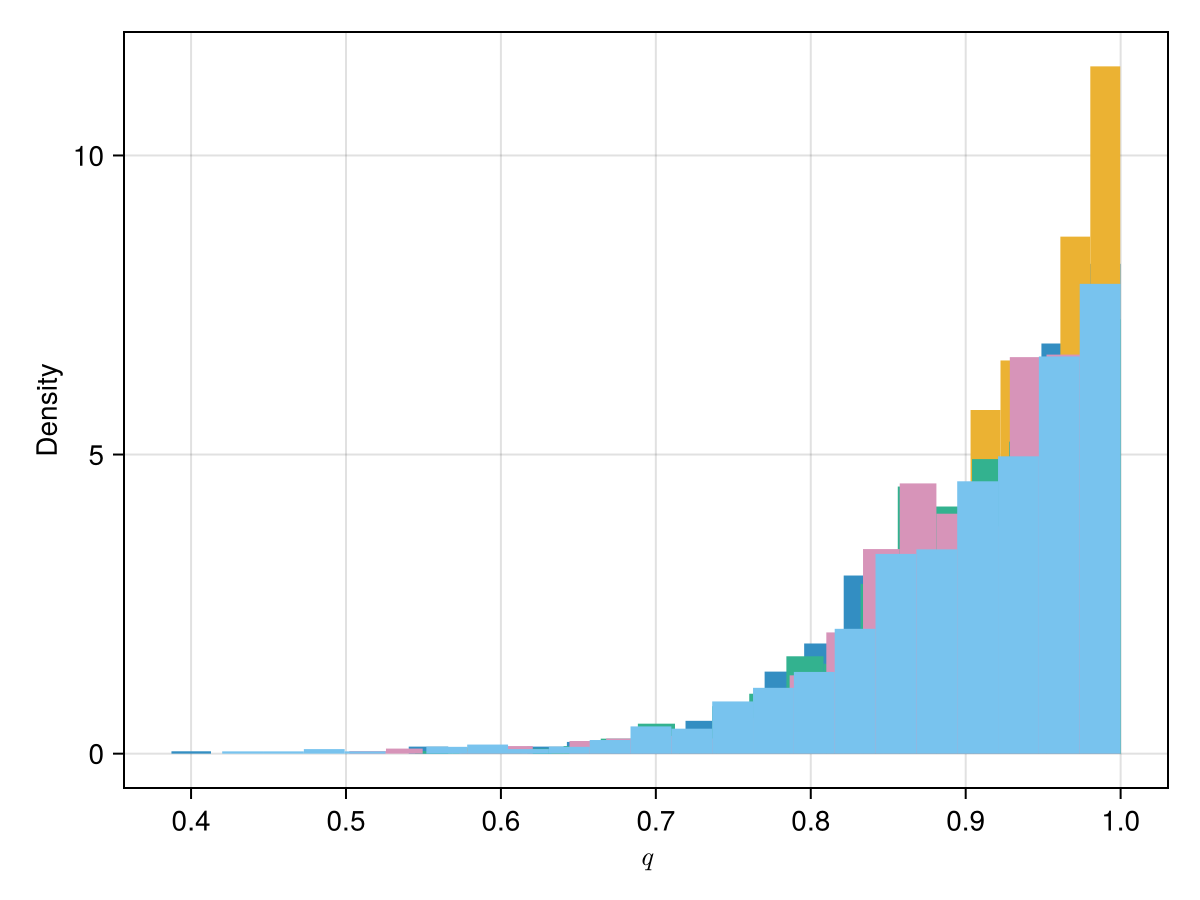

In [64]:
f = Figure()
a = Axis(f[1,1], xlabel=L"q", ylabel="Density")

for _ in 1:5
    i = rand(1:length(qs_obs))
    x = vec(exact_trace["qs[$i]"])
    hist!(a, x, normalization=:pdf, bins=scotts_rule_bins(x))
end

f

Let's draw 1k samples per observation, and then have a look at the resulting sampling:

In [65]:
Nsamp = 1000
q_samples = [rand(truncated(Normal(qobs, sigma_obs), 0, 1), Nsamp) for qobs in qs_obs]
q_samples = stack(q_samples, dims=2)

1000×100 Matrix{Float64}:
 0.678396   0.891735  0.794789  0.882403  …  0.947666  0.782129  0.757465
 0.985233   0.965194  0.362675  0.86915      0.83824   0.831362  0.511334
 0.949697   0.782356  0.937107  0.817709     0.601339  0.667981  0.597126
 0.835152   0.811151  0.594776  0.816653     0.987546  0.799265  0.589032
 0.672527   0.818368  0.626837  0.694803     0.98431   0.689446  0.608168
 0.821054   0.871796  0.599746  0.850387  …  0.964147  0.595138  0.24536
 0.0805488  0.656046  0.82341   0.930063     0.799174  0.795357  0.31406
 0.250916   0.955066  0.317902  0.727025     0.909899  0.48496   0.781655
 0.889977   0.718159  0.290263  0.939276     0.978323  0.906438  0.482439
 0.713404   0.666269  0.746199  0.886371     0.745702  0.889066  0.35446
 ⋮                                        ⋱                      
 0.222228   0.325222  0.760778  0.933952     0.921529  0.817097  0.606258
 0.727991   0.921967  0.775158  0.946505     0.945428  0.806682  0.449068
 0.733878   0.78627   0

This model is the samples-based marginalization over the true $q$ in the likelihood; note that we keep track of the effective sample number for each observation in computing the integral.

In [66]:
@model function samples_model(q_samples)
    mu ~ Normal(0.0, 1.0)
    sigma ~ truncated(Normal(0.0, 1.0), 0.0, Inf)

    logps = logpdf.(Ref(truncated(Normal(mu, sigma), 0, 1)), q_samples)

    marginal_logls = logsumexp(logps, dims=1)

    log_neff = vec(2.0 .* marginal_logls .- logsumexp(logps .* 2, dims=1))
    neff := exp.(log_neff)

    Turing.@addlogprob! sum(marginal_logls)
end

samples_model (generic function with 2 methods)

In [67]:
samples_trace = sample(samples_model(q_samples), NUTS(1000, 0.8; adtype=AutoEnzyme(mode=Enzyme.set_runtime_activity(Enzyme.Reverse))), 1000)

Sampling   0%|                                          |  ETA: N/A
┌ Info: Found initial step size
│   ϵ = 0.05
└ @ Turing.Inference /Users/wfarr/.julia/packages/Turing/H4T0b/src/mcmc/hmc.jl:226
Sampling   0%|▎                                         |  ETA: 0:08:44
Sampling   1%|▍                                         |  ETA: 0:05:03
Sampling   2%|▋                                         |  ETA: 0:03:43
Sampling   2%|▉                                         |  ETA: 0:03:12
Sampling   2%|█                                         |  ETA: 0:02:49
Sampling   3%|█▎                                        |  ETA: 0:02:32
Sampling   4%|█▌                                        |  ETA: 0:02:32
Sampling   4%|█▋                                        |  ETA: 0:02:26
Sampling   4%|█▉                                        |  ETA: 0:02:23
Sampling   5%|██▏                                       |  ETA: 0:02:18
Sampling   6%|██▎                                       |  ETA: 0:02:17
Sampling   6

Chains MCMC chain (1000×116×1 Array{Float64, 3}):

Iterations        = 1001:1:2000
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 113.68 seconds
Compute duration  = 113.68 seconds
parameters        = mu, sigma, neff[1], neff[2], neff[3], neff[4], neff[5], neff[6], neff[7], neff[8], neff[9], neff[10], neff[11], neff[12], neff[13], neff[14], neff[15], neff[16], neff[17], neff[18], neff[19], neff[20], neff[21], neff[22], neff[23], neff[24], neff[25], neff[26], neff[27], neff[28], neff[29], neff[30], neff[31], neff[32], neff[33], neff[34], neff[35], neff[36], neff[37], neff[38], neff[39], neff[40], neff[41], neff[42], neff[43], neff[44], neff[45], neff[46], neff[47], neff[48], neff[49], neff[50], neff[51], neff[52], neff[53], neff[54], neff[55], neff[56], neff[57], neff[58], neff[59], neff[60], neff[61], neff[62], neff[63], neff[64], neff[65], neff[66], neff[67], neff[68], neff[69], neff[70], neff[71], neff[72], neff[73], neff[74], neff[75], neff[76], neff[77], neff[78]

Sampling here is also shit, and the minimum number of effective samples per event is pretty small; nevertheless, let's proceed (it will turn out to give consistent inferences, so good enough)?

In [68]:
describe(samples_trace)

Chains MCMC chain (1000×116×1 Array{Float64, 3}):

Iterations        = 1001:1:2000
Number of chains  = 1
Samples per chain = 1000
Wall duration     = 113.68 seconds
Compute duration  = 113.68 seconds
parameters        = mu, sigma, neff[1], neff[2], neff[3], neff[4], neff[5], neff[6], neff[7], neff[8], neff[9], neff[10], neff[11], neff[12], neff[13], neff[14], neff[15], neff[16], neff[17], neff[18], neff[19], neff[20], neff[21], neff[22], neff[23], neff[24], neff[25], neff[26], neff[27], neff[28], neff[29], neff[30], neff[31], neff[32], neff[33], neff[34], neff[35], neff[36], neff[37], neff[38], neff[39], neff[40], neff[41], neff[42], neff[43], neff[44], neff[45], neff[46], neff[47], neff[48], neff[49], neff[50], neff[51], neff[52], neff[53], neff[54], neff[55], neff[56], neff[57], neff[58], neff[59], neff[60], neff[61], neff[62], neff[63], neff[64], neff[65], neff[66], neff[67], neff[68], neff[69], neff[70], neff[71], neff[72], neff[73], neff[74], neff[75], neff[76], neff[77], neff[78]

This is pretty small---makes me a bit nervous about the quality of the sampling when you only have 3 effective samples in computing some Monte Carlo integral, but below the result is pretty consistent, so :shrug:?

In [71]:
min_neff = Inf
for i in 1:N
    min_ne = minimum(samples_trace["neff[$i]"])
    min_neff = min(min_neff, min_ne)
end
println("Minimum neff: $min_neff")

Minimum neff: 3.465912282811678


Here is the result using the Monte-Carlo integrals compared to the exact likelihood; looks identical to me?

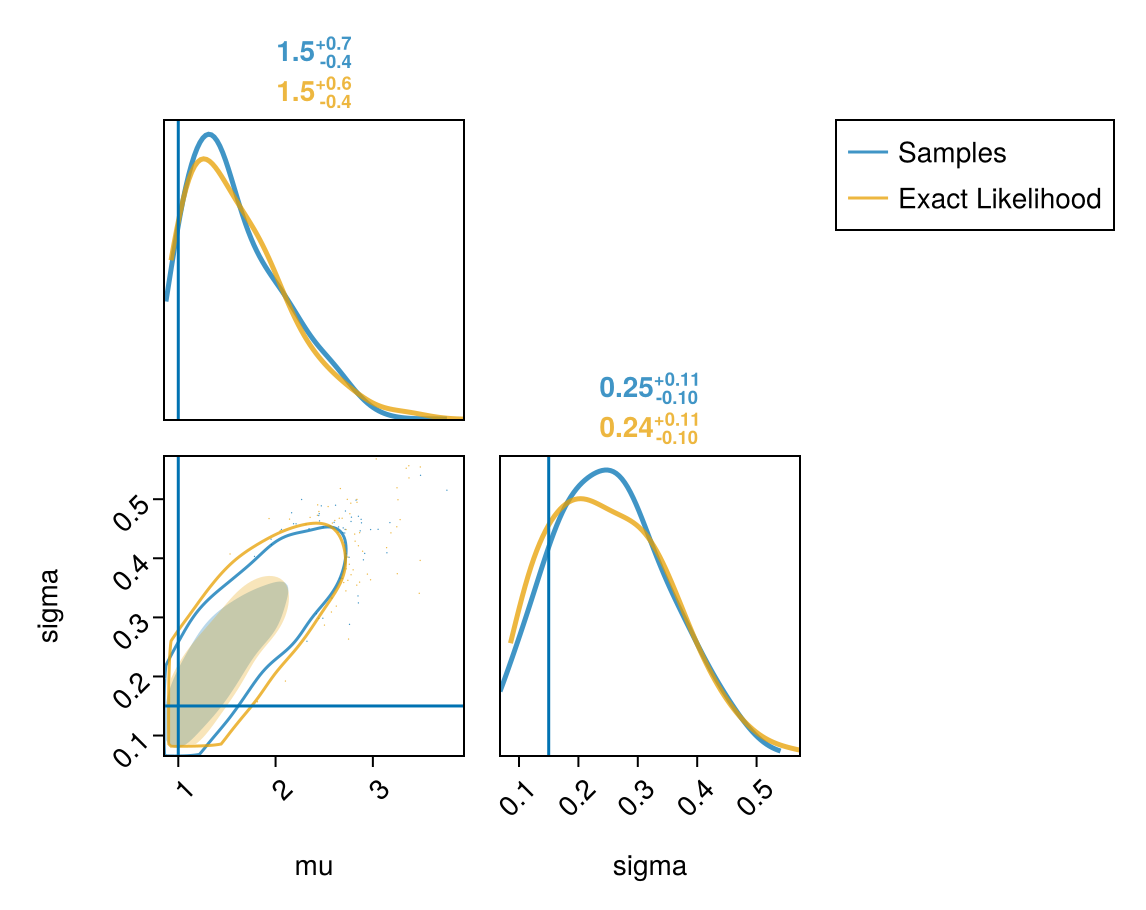

In [77]:
csamples = Makie.wong_colors(0.75)[1]
cexact = Makie.wong_colors(0.75)[2]
pairplot(PairPlots.Series(samples_trace[[:mu, :sigma]], label="Samples", color=csamples, strokecolor=csamples), PairPlots.Series(exact_trace[[:mu, :sigma]], label="Exact Likelihood", color=cexact, strokecolor=cexact), PairPlots.Truth((; mu = mu_true, sigma = sigma_true)))